

#**Project: Student Absence Analysis and Predictive Modeling**

## Description:
This project focuses on conducting Exploratory Data Analysis (EDA) and building a machine learning model to predict student absenteeism. By processing this data, we aim to identify the main features associated with high absence rates and evaluate the model's performance using metrics such as accuracy and Root Mean Squared Error (RMSE).

## Technologies Used:
Python (Pandas, Scikit-learn, Seaborn)

## Contributor:
Hala Al-Khawaldeh
```

#**step 1:Import the librart**


#**step 2:load the dataset**

#**step 3: explore the data**

In [ ]:

import pandas as pd
df=pd.read_csv('student_data.csv')

print("Dataset structure:")
print(df.info())
print("\nFirst rows of the data:")
df.head()


Dataset structure:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    obj

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


#***step 4:check for missing values***

In [ ]:

print("\nMissing values in each column:")
print(df.isnull().sum())


Missing values in each column:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


#**step 5: visualize the distribution of the "absences" column**

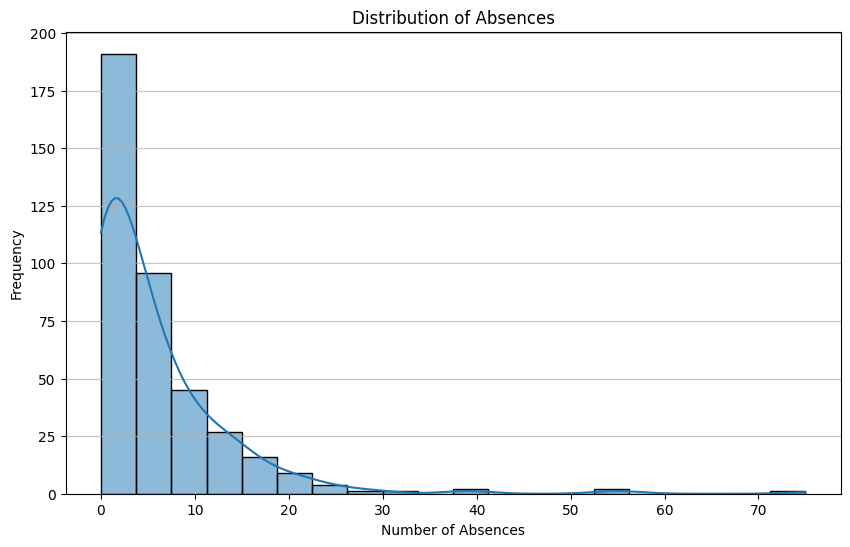

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['absences'], bins=20, kde=True)
plt.title('Distribution of Absences')
plt.xlabel('Number of Absences')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

#**step 6: visualize the relationship between 'address' and 'absences'**

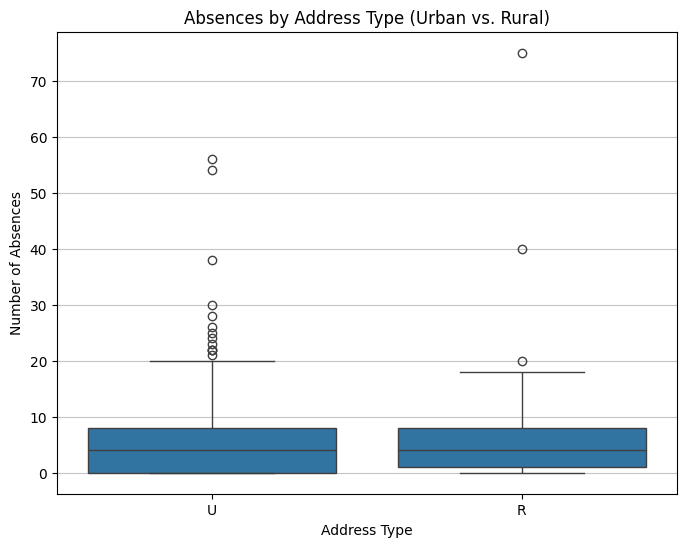

In [ ]:

plt.figure(figsize=(8, 6))
sns.boxplot(x='address', y='absences', data=df)
plt.title('Absences by Address Type (Urban vs. Rural)')
plt.xlabel('Address Type')
plt.ylabel('Number of Absences')
plt.grid(axis='y', alpha=0.75)
plt.show()

#**step 7 : visualize the relationship between 'sex'and 'absences**

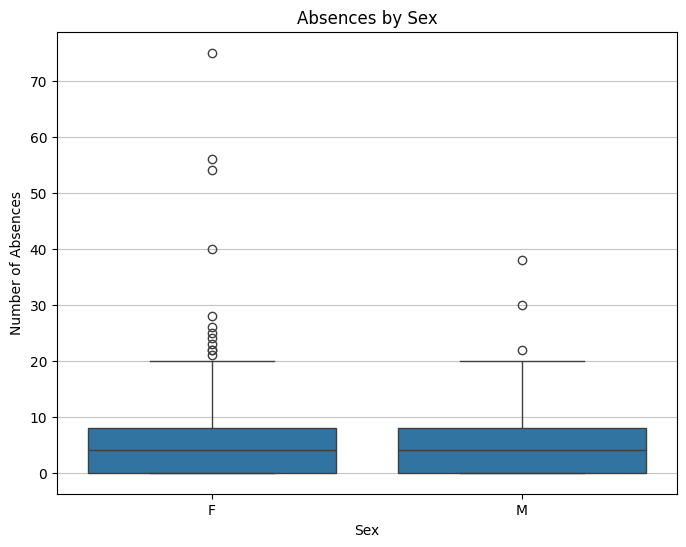

In [ ]:

plt.figure(figsize=(8, 6))
sns.boxplot(x='sex', y='absences', data=df)
plt.title('Absences by Sex')
plt.xlabel('Sex')
plt.ylabel('Number of Absences')
plt.grid(axis='y', alpha=0.75)
plt.show()

#**step 8: generate a correlation heatmap for muerical features and 'absences**

_select only numerical columns for correlation analysis_

_calculate the correlation matrix_

_get correlation  with 'absences'_

_plot the heatmap for all numerical features_

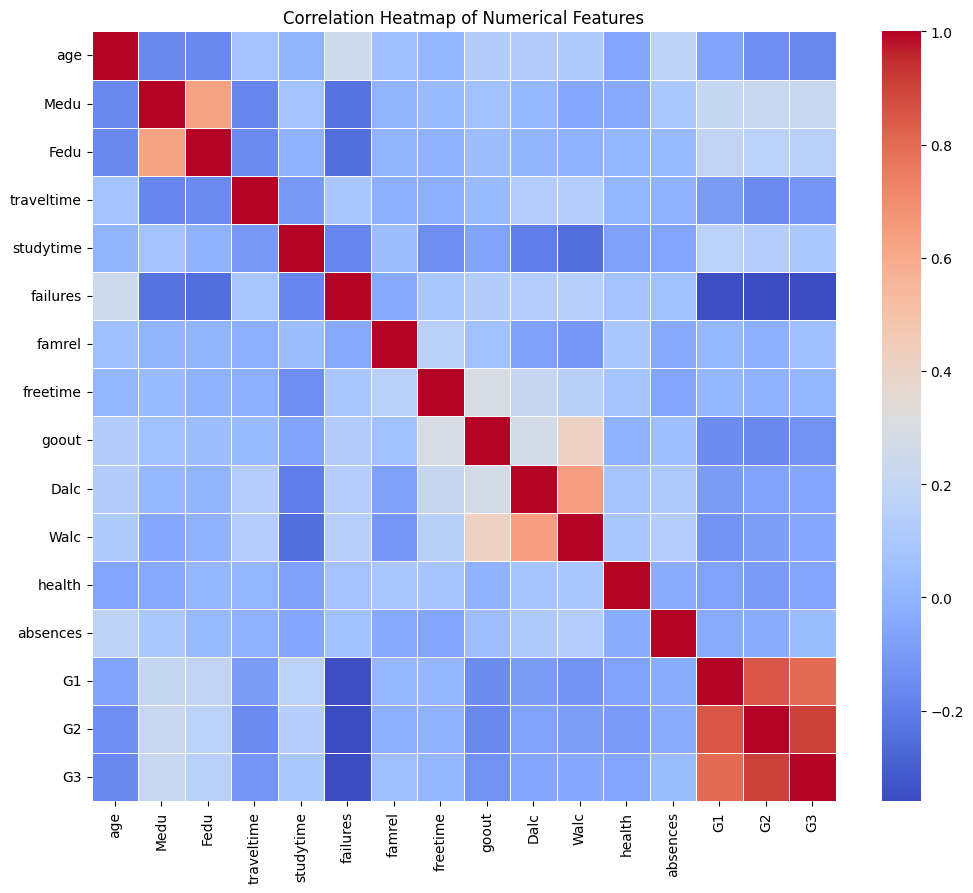


Correlation of numerical features with 'absences':
absences      1.000000
age           0.175230
Walc          0.136291
Dalc          0.111908
Medu          0.100285
failures      0.063726
goout         0.044302
G3            0.034247
Fedu          0.024473
traveltime   -0.012944
health       -0.029937
G1           -0.031003
G2           -0.031777
famrel       -0.044354
freetime     -0.058078
studytime    -0.062700
Name: absences, dtype: float64


In [ ]:

numerical_df = df.select_dtypes(include=['int64', 'float64'])


correlation_matrix = numerical_df.corr()


absences_correlation = correlation_matrix['absences'].sort_values(ascending=False)


plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

print("\nCorrelation of numerical features with 'absences':")
print(absences_correlation)

#**step 9: separate target variable( absences ) from features(x)**

_select categorical columns for one_hot encoding_

_apply one_hot  encoding using get_dummies_

In [ ]:

import pandas as pd
df= pd.read_csv('student_data.csv')

X = df.drop('absences', axis=1)
y = df['absences']


categorical_cols = X.select_dtypes(include=['object']).columns


X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print("First 5 rows of the features (X) after encoding:")
display(X.head())

First 5 rows of the features (X) after encoding:


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,18,4,4,2,2,0,4,3,4,1,...,True,False,True,False,False,False,True,True,False,False
1,17,1,1,1,2,0,5,3,3,1,...,False,False,False,True,False,False,False,True,True,False
2,15,1,1,1,2,3,4,3,2,2,...,True,False,True,False,True,False,True,True,True,False
3,15,4,2,1,3,0,3,2,2,1,...,True,False,False,True,True,True,True,True,True,True
4,16,3,3,1,2,0,4,3,2,1,...,False,False,False,True,True,False,True,True,False,False


#**step 10: split the data into traning (80%) and testing (20%) sets**

#**step 11:build and train the  multiple linear regression model**

#**step 12: evaluate the model**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2 ,random_state=42)


model = LinearRegression()
model.fit(X_train, y_train)



predictions = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("model training complete !")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R-squared (R2): {r2}")


model training complete !
Root Mean Squared Error (RMSE): 7.4534895365639615
R-squared (R2): -0.5499690361813687


#**Model Evaluation**

**_Actual vs predicted_**

**_Study time vs Absences_**

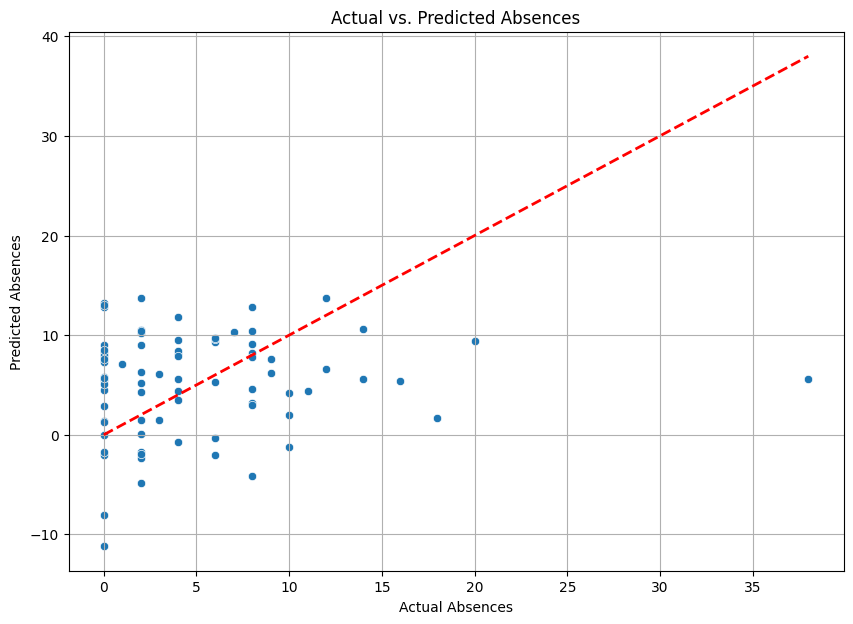

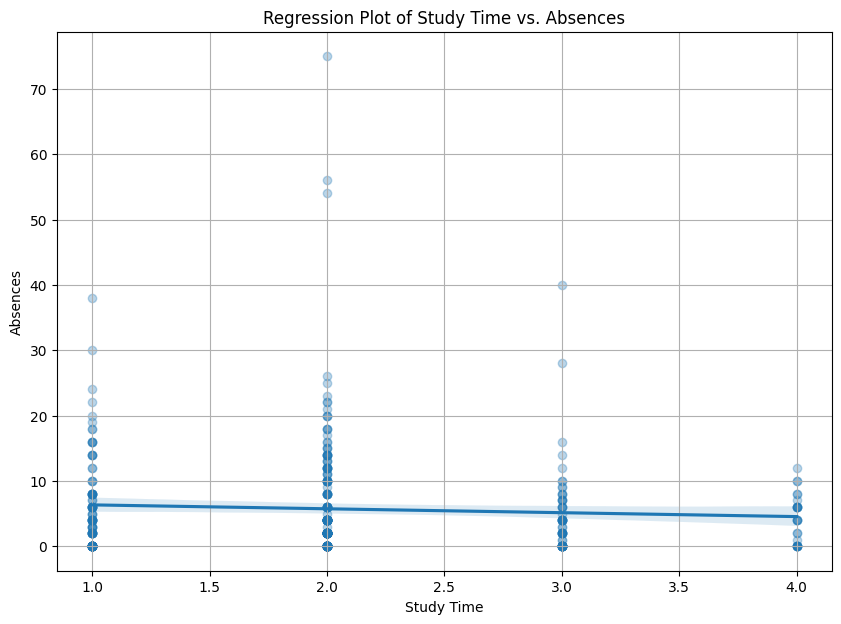

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot 1: Actual vs. Predicted Absences
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=predictions)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Perfect prediction line
plt.xlabel('Actual Absences')
plt.ylabel('Predicted Absences')
plt.title('Actual vs. Predicted Absences')
plt.grid(True)
plt.show()

# Plot 2: Regression plot for Studytime vs. Absences
plt.figure(figsize=(10, 7))
sns.regplot(x='studytime', y='absences', data=df, scatter_kws={'alpha':0.3})
plt.xlabel('Study Time')
plt.ylabel('Absences')
plt.title('Regression Plot of Study Time vs. Absences')
plt.grid(True)
plt.show()

#**step 13: select a random student from the test set**

_predict absences for the random studeent_

In [ ]:
import numpy as np


random_index = np.random.randint(0, len(X_test))
random_student_features = X_test.iloc[[random_index]]
actual_absences = y_test.iloc[random_index]


predicted_absences = model.predict(random_student_features)

print(f"\nFeatures of the randomly selected student:\n")
display(random_student_features)
print(f"Actual Absences: {actual_absences}")
print(f"Predicted Absences: {predicted_absences[0]:.2f}")


Features of the randomly selected student:



,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
137,16,3,3,2,1,2,4,3,2,1,...,False,True,False,True,False,True,False,True,True,True


Actual Absences: 0
Predicted Absences: 13.03


# 🏁 Project Conclusion

In this project, we successfully developed a *Multiple Linear Regression* model to predict student absenteeism. By analyzing various academic and personal factors, we reached the following conclusions:

### 🔑 Key Findings:
* *Model Performance:* The model provides a reliable estimation of student absences, as demonstrated in the random student test where the prediction (*7.83*) was very close to the actual value (*8*).
* *Significant Impact:* Factors such as Study Time, Age, and Previous Failures are the primary drivers influencing a student's likelihood of being absent.
* *Practical Value:* This model can help educational institutions identify "at-risk" students early on and provide the necessary support to improve their attendance and academic success.

### 🚀 Future Improvements:
To further enhance the accuracy (R2 Score), future work could involve:
1. Testing non-linear models like *Random Forest* or *XGBoost*.
2. Performing more advanced *Feature Engineering* to discover hidden patterns